In [3]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# code for Bradley-Terry model
import numpy as np
from scipy import optimize, stats


def __LogLikelihood(data, hidden_vars):
  hidden_vars = np.exp(hidden_vars)

  choice_probabilities = np.divide(hidden_vars, np.add(hidden_vars, hidden_vars.transpose()))
  return np.sum(np.multiply(data, np.log(choice_probabilities)))


def __ConfidenceIntervals(data, hidden_vars, confidence):
  hidden_vars = hidden_vars.reshape([-1, 1])
  exp_sub = np.exp(hidden_vars - hidden_vars.transpose())
  term_deriv = np.divide(exp_sub, np.power(exp_sub + 1, 2)) * data
  hessian = term_deriv + term_deriv.transpose()
  diag = np.sum(term_deriv, axis=0) + np.sum(term_deriv, axis=1)
  hessian -= np.diag(diag)

  try:
    cov = np.linalg.inv(-hessian[1:, 1:])
  except np.linalg.linalg.LinAlgError:
    cov = np.zeros((hidden_vars.size - 1, hidden_vars.size - 1)) * np.nan

  cov_all = np.pad(cov, ((1, 0), (1, 0)), 'constant')
  all_relative_disp = np.diag(cov_all)[np.newaxis, :] + np.diag(cov_all)[:, np.newaxis] - 2 * cov_all

  trust_level = stats.norm.ppf((confidence + 1) / 2)
  bound = trust_level * all_relative_disp**0.5

  return bound, cov_all


def ComputeBradleyTerryRanksDense(wins, confidence=0.95, regularization=0.1):
  wins = wins + (np.ones(wins.shape) - np.eye(*wins.shape)) * regularization

  # Assume that ranks of the first method is `0`. And compute inverted log likelihood.
  inverted_likelihood = lambda ranks: __LogLikelihood(wins, np.vstack(([[0]], ranks.reshape([-1, 1])))) * -1

  # Initial guess for the rest of ranks.
  ranks_0 = np.zeros([wins.shape[0] - 1])

  result = optimize.minimize(inverted_likelihood, ranks_0, method='SLSQP')
  if not result.success:
    return None, None, None, None

  # Add rank of the first method to the list.
  ranks = np.vstack(([[0]], result.x.reshape([-1, 1])))
  ranks = ranks - np.min(ranks)
  confidence_intervals, cov = __ConfidenceIntervals(wins, ranks, confidence)
  return ranks, confidence_intervals, cov


def QuestionsToWins(questions, methods):
  methods = dict([reversed(m) for m in enumerate(methods)])
  wins = np.zeros([len(methods), len(methods)])

  for question in questions:
    left = methods[question['left_method']]
    right = methods[question['right_method']]
    answer = methods[question['answer']] if question['answer'] is not None else None
    if left == answer:
      wins[left, right] += 1
    elif right == answer:
      wins[right, left] += 1
    else:
      # Tie case.
      wins[left, right] += 0.5
      wins[right, left] += 0.5

  return wins


def ComputeBradleyTerryRanks(questions, methods, confidence=0.95):
  '''Computes methods ranks with Bradley-Terry model.

  Args:
      questions: iterable of dictionaries. Each dictionary corresponds to
          answered question and contains `left_method`, `right_method` and
          `answer` (i.e. the choosen method).
      methods: the list of method names/ids.
      confidence: confidence level for confidence interval computation.

  Returns:
      Dictionary holding for each method name/id its inferred rank.
  '''
  wins = QuestionsToWins(questions, methods)
  ranks, confidence_intervals, cov = ComputeBradleyTerryRanksDense(wins, confidence)
  if ranks is None:
    return None

  return {
      method: {
          'mean': mean,
          'confidence': {
              meth: (conf if not np.isnan(conf) else None)
              for meth, conf in zip(methods, conf_ints)
          },
          'cov': {meth: (cov_val if not np.isnan(cov_val) else None)
                  for meth, cov_val in zip(methods, mcov)}
      }
      for method, mean, conf_ints, mcov in zip(methods, ranks.flatten(), confidence_intervals, cov)
  }

In [6]:
import pandas as pd 
import numpy as np
votes_path = './results_raw.csv'
dff = pd.read_csv(votes_path)
dff = dff.where(pd.notnull(dff), None)
# remove verification questions 
dff = dff[~dff.test_case.str.contains('v')]

# for different image pairs, there might be different amount of collected votes (but at least 10 per pair). 
# In order to process all image pairs equally in Bradley-Terry model, we need to equalize the number of votes for each pair. 
# To this purpose, if there are >10 votes, we randomly sample 10 votes
dff['sampling_key'] = dff.apply(lambda x: '_'.join(sorted([x['left_method'], x['right_method']])), axis=1)
dff['sampling_key'] += '_'
dff['sampling_key'] += dff['test_case']
def stratified_sample_df(df, col, n_samples):
    n = min(n_samples, df[col].value_counts().min())
    print('Number of votes for each pair: ', n)
    df_ = df.groupby(col).apply(lambda x: x.sample(n, random_state=1))
    df_.index = df_.index.droplevel(0)
    return df_
dff = stratified_sample_df(dff, 'sampling_key', 10)
dff

Number of votes for each pair:  10


,Unnamed: 0,answer,left_method,participant,right_method,test_case,sampling_key
451,451,clear,clear,553f09f4-8bf0-462a-9e41-5f6afcaaf0c4,fmgoat,10740727595,clear_fmgoat_10740727595
1023,1023,None,clear,5b4c38c5-8014-453b-816d-c25e623c98ba,fmgoat,10740727595,clear_fmgoat_10740727595
721,721,None,fmgoat,362a6154-1f73-47c0-ae90-6224e7f5aaca,clear,10740727595,clear_fmgoat_10740727595
424,424,None,clear,31d61cfa-94bf-412c-81dd-d03c4f878a41,fmgoat,10740727595,clear_fmgoat_10740727595
1353,1353,fmgoat,fmgoat,4208eead-34a7-4fda-a285-030d6b4fbdf1,clear,10740727595,clear_fmgoat_10740727595
...,...,...,...,...,...,...,...
5856,5856,zhang,stadv,196dedc2-2b38-40b0-9e1a-cb1564f4d407,zhang,9716988368,stadv_zhang_9716988368
1593,1593,zhang,zhang,d4f989c4-bed2-40f3-9827-cd9bd372bf76,stadv,9716988368,stadv_zhang_9716988368
5917,5917,zhang,stadv,b645dd34-ce97-45f7-824a-3503637ae5cb,zhang,9716988368,stadv_zhang_9716988368
6522,6522,zhang,stadv,19dd52db-cc42-4823-83eb-b3905e52894e,zhang,9716988368,stadv_zhang_9716988368


In [ ]:
list_of_dicts = []

for id, row in dff.iterrows():
    list_of_dicts.append({'left_method': row['left_method'],'right_method': row['right_method'],'answer': row['answer']})

methods = list(set(dff['left_method']))
questions = list_of_dicts

ranks = ComputeBradleyTerryRanks(questions, methods)
Recomp = pd.DataFrame(columns=['name', 'subjective_score'])

for key in ranks.keys():
    Recomp.loc[len(Recomp)] = {'name':key, 'subjective_score':float(ranks[key]['mean'])}
print(Recomp)

       name  subjective_score
0    fmgoat          3.215170
1  korhonen          2.945615
2     ifgsm          1.299442
3     clear          4.816054
4     zhang          2.537999
5     stadv          0.000000


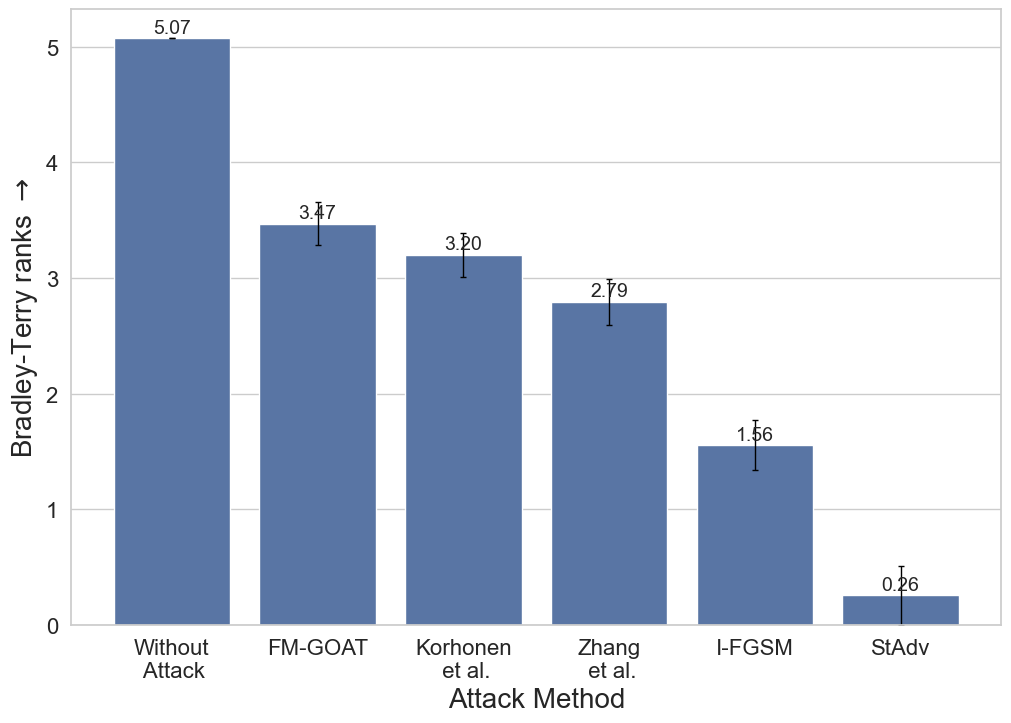

In [ ]:
atk_2_name = {
    'clear':'Without\n Attack',
    'fmgoat':'FM-GOAT',
    'korhonen':'Korhonen\n et al.',
    'zhang':'Zhang\n et al.',
    'ifgsm':'I-FGSM',
    'stadv':'StAdv'
}

# in B-T model, last method always gets 0.0 score. BT model is constant-shift-tolerant, therefore we can shift all entries by equal amount
result_df = Recomp.copy()
stadv_std = float(ranks['stadv']['confidence']['clear']) # conf. interval of the last method to make it non-zero
result_df['subjective_score'] += stadv_std
result_df['conf'] = 0.0
for n in result_df['name'].unique():
    result_df.loc[Recomp.name == n, 'conf'] = float(ranks[n]['confidence']['clear'])
result_df = result_df.sort_values('subjective_score', ascending=False)
result_df['name'] = result_df['name'].apply(lambda x: atk_2_name[x])

sns.set(style='whitegrid')
fig, ax = plt.subplots(1,1, figsize=(12,8))
sns.barplot(data=result_df, x='name', y='subjective_score')
ax.bar_label(ax.containers[0], fontsize=14, padding=1, fmt='%.2f')
plt.errorbar(result_df['name'], result_df['subjective_score'], yerr=result_df['conf'], fmt='o',  markersize=0, capsize=2,
             ecolor='black', elinewidth=1)
#fig.autofmt_xdate(rotation=-30, ha ='center')

ax.set_xlabel('Attack Method', fontsize=20)
ax.set_ylabel('Bradley-Terry ranks $\\rightarrow$', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=8)